In [1]:
# try to perform a quadratic regression

     student_id  age  gender  study_hours  class_attendance  internet_access  \
1             2   23     3.0         3.37              64.8              1.0   
8             9   18     3.0         2.89              92.0              1.0   
17           18   18     1.0         0.40              64.9              1.0   
26           27   20     1.0         5.76              55.7              0.0   
32           33   17     3.0         5.68              46.4              1.0   
37           38   23     1.0         3.96              84.5              1.0   
43           44   19     1.0         1.89              52.0              1.0   
49           50   23     1.0         6.90              76.3              1.0   
50           51   23     1.0         4.60              64.8              1.0   
60           61   24     2.0         4.26              46.1              1.0   
65           66   19     3.0         0.08              50.9              1.0   
69           70   20     3.0         2.8

C:\Users\chius\AppData\Local\Temp\ipykernel_18728\2479599682.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_init=df.head(200)[df['course']=='bca']
C:\Users\chius\AppData\Local\Temp\ipykernel_18728\2479599682.py:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_reg=df_init.drop(columns=['course','study_method'],errors='ignore').replace(parameter)


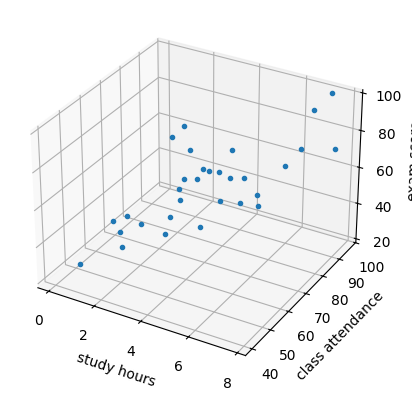

In [2]:
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as LiR
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

def median(data):
    data=deepcopy(data)
    N=len(data)
    if N//2:
        median=(data[N//2+1]+data[N//2])/2
    else:
        median=(data[(N+1)//2])
    return median

def M(data,k): #kth central moment
    # central moments has lots of use,
    # for example: (--> means related to)
    # k=0-->total
    # k=1-->mean, k=2-->variance
    # k=3-->skewness, k=4-->kurtosis
    data=deepcopy(data)
    Mk=0
    for i in data:
        Mk+=(i)**k
    return Mk

# no need for any path since the csv files is already right a branch file of chius
df = pd.read_csv("Example to regressions.csv")
df_init=df.head(200)[df['course']=='bca']
#df_init=df
N=df_init.shape[0]

parameter={'gender':{'male':1.0,'female':2.0,'other':3.0},
           'internet_access':{'yes':1.0,'no':0.0},
           'sleep_quality':{'poor':1.0,'average':2.0,'good':3.0},
           'facility_rating':{'low':1.0,'medium':2.0,'high':3.0},
           'exam_difficulty':{'easy':3.0,'moderate':2.0,'hard':1.0}}

df_reg=df_init.drop(columns=['course','study_method'],errors='ignore').replace(parameter)
print(df_reg)
df_np=df_reg.to_numpy()

# graph of most important factor (study_hours) against output (exam_score)
fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
ax.plot(df_reg['study_hours'],df_reg['class_attendance'],df_reg['exam_score'],'.')
ax.set_xlabel('study hours')
ax.set_ylabel('class attendance')
ax.set_zlabel('exam score')
plt.show()

In [3]:
A=np.ones((N,2))
A[:,1]=df_np[:,3] #study hour data

f=df_np[:,-1]
x=np.zeros(2)

In [4]:
# for n-th order fitting:
#
#A=np.ones((N,1+2*n))
#A[:,1+2*(i-1):1+2*i]=df_np['first_factor']**i
#A[:,1+2*(i+1):1+4*(i-1)]=df_np['second_factor']**i
#...
#
#f=['output']
#x=np.zeros(1+2*n)

In [5]:
# the conjugate gradient method to solve Ax=f, where A=X.T@X, a large matrix

r=A.T@f-(A.T@np.dot(A,x))  # transpose(A)*(f-Ax)
p=r.copy()
it=0

while True:
    it+=1
    inter=A@p #these 2 intermediate steps are used to accelerate
    inter2=A.T@inter #the code and reduce memory use if A is too large
    a=np.inner(r,r)/(np.dot(p,inter2))
    x+=a*p
    r_new=r-a*inter2
    if np.max(abs(r_new))<1e-4:
        break
    else:
        b=np.inner(r_new,r_new)/np.inner(r,r)
        p=r_new+b*p
        r=r_new

print(it)
print(x)

2
[34.23291549  6.71630787]


In [6]:
xpts=np.linspace(0,10,1001)
curve=0
for i in range(2):
    curve+=x[i]*xpts**i

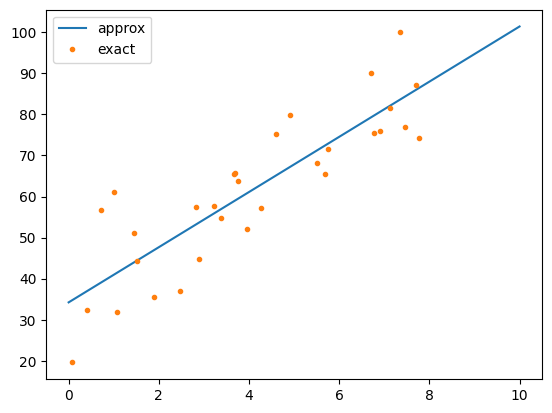

In [7]:
fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(xpts,curve,label='approx')
ax.plot(df_reg['study_hours'],df_reg['exam_score'],'.',label='exact')
ax.legend()
plt.show()

In [8]:
model=LiR().fit(A[:,1:],f)
m1,m2=model.coef_
c=model.intercept_
print(model.coef_)
print(model.intercept_)

xpts=np.linspace(0,10,1001)
curve=c*np.ones(1001)+m1*xpts+m2*xpts**2

fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(xpts,curve,label='approx using sklearn')
ax.plot(df_reg['study_hours'],df_reg['exam_score'],'.',label='exact')
ax.legend()
plt.show()

ValueError: not enough values to unpack (expected 2, got 1)